# 1- Introduction to SVM

# - About the Diabetes Data

Original Source: National Institute of Diabetes and Digestive and Kidney Diseases.
Public Source: Kaggle (Pima Indians Diabetes Database).
----------------------------------------
The dataset consists of several medical predictor variables and one target variable, `Outcome`. Predictor variables include the number of pregnancies the patient has had, their BMI, insulin level, age, glucose, and more.

The `Outcome` field contains the diagnosis:
* `0` = Negative (No Diabetes)
* `1` = Positive (Diabetes)

### row = patient record
### column = diagnostic attribute / dimension
### target = prediction (Outcome)

# 2- Necessary imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 4- Load Data From CSV File

We will use the `pandas` library to load the diabetes dataset. 
The dataset contains 8 medical predictor features and 1 target variable (`Outcome`).

- **Features (X):** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age.
- **Target (y):** Outcome (`0` = Healthy, `1` = Diabetic).

### row = patient record
### column = medical attribute (feature)
### target = prediction (Outcome)

In [24]:
df = pd.read_csv("diabetes.csv")

In [25]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [27]:
df.shape

(768, 9)

In [28]:
df.size

6912

In [29]:
df.count()

Pregnancies                 768
Glucose                     768
BloodPressure               768
SkinThickness               768
Insulin                     768
BMI                         768
DiabetesPedigreeFunction    768
Age                         768
Outcome                     768
dtype: int64

In [30]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# 5- Distribution of the classes

In [31]:
negative = df[df['Outcome']==0][0:200]
positive = df[df['Outcome']==1][0:200]

<Axes: xlabel='Glucose', ylabel='BMI'>

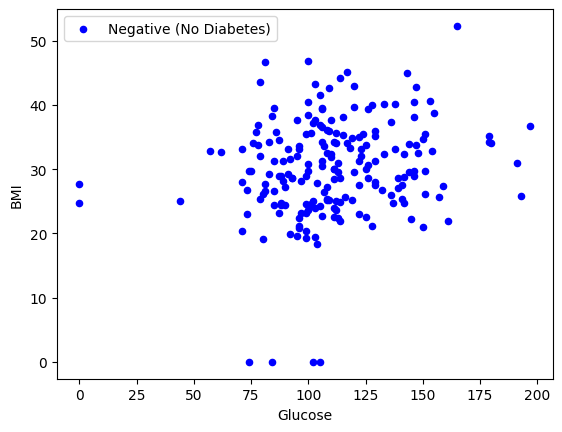

In [32]:
negative.plot(kind='scatter', x='Glucose', y='BMI', color='blue', label='Negative (No Diabetes)')


<Axes: xlabel='Glucose', ylabel='BMI'>

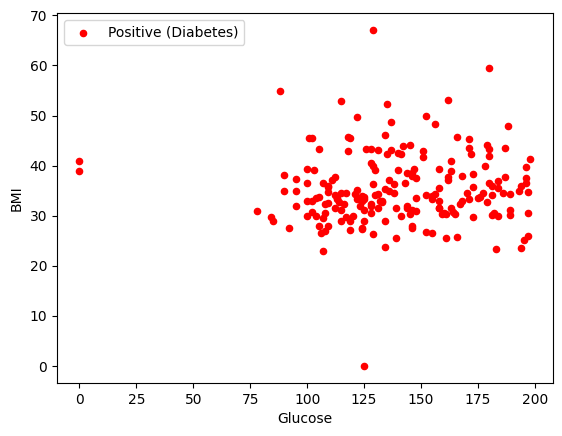

In [33]:
positive.plot(kind='scatter', x='Glucose', y='BMI', color='red', label='Positive (Diabetes)')

# 6- Checking Data Types
All columns in this dataset should be numeric (int64 or float64) so they can be fed directly into the SVM model.

In [34]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

# 7- Defining Features (X) and Target (y)
We select the medical features to be our 'X' and the 'Outcome' to be our 'y'.

In [36]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [37]:
feature = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
X = np.asarray(feature)

y = np.asarray(df['Outcome'])

# 8- Divide the data into Train/Test and Data Preprocessing
The diabetes dataset contains 768 rows. We will split the data into 80% for training and 20% for testing.
We also apply **StandardScaler** to normalize the features.

In [38]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [40]:
x_train.shape

(614, 8)

In [41]:
y_train.shape

(614,)

In [42]:
x_test.shape

(154, 8)

In [43]:
y_test.shape

(154,)

# 9- Model Training (SVM)
We train our Support Vector Machine model using the RBF kernel.

In [44]:
from sklearn import svm

'''
We changed the kernel from 'linear' to 'rbf' to better handle complex, non-linear relationships in the medical data.
We also set C=1.0 and gamma='scale' to optimize the model's performance.
'''

classifier = svm.SVC(kernel='rbf', gamma='scale', C=1.0)
classifier.fit(x_train, y_train)
y_predict = classifier.predict(x_test)

# 10- Evaluation (Results)

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       102
           1       0.67      0.62      0.64        52

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



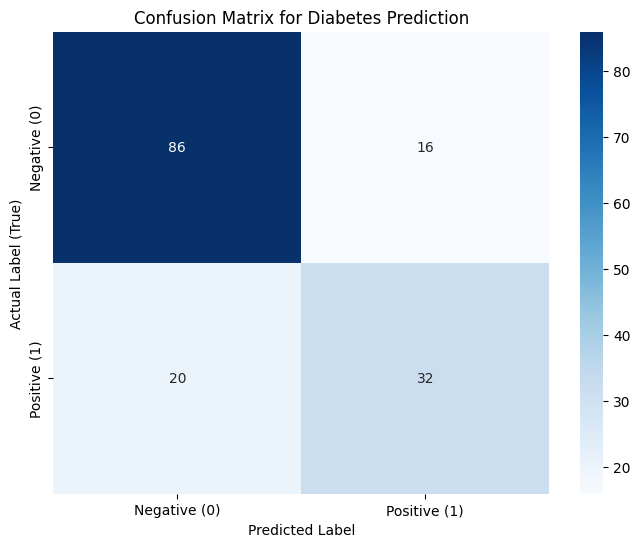

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix based on true labels and predictions
cm = confusion_matrix(y_test, y_predict)

# Plot the confusion matrix using Seaborn heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

# Add labels and title for clarity
plt.title('Confusion Matrix for Diabetes Prediction')
plt.ylabel('Actual Label (True)')
plt.xlabel('Predicted Label')
plt.show()